In [3]:
import pandas as pd
import numpy as np
import datetime as dt
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from skimpy import skim
import scipy.stats as stats
from IPython.display import Markdown as md
from mpl_toolkits.mplot3d import Axes3D
import folium


# Run data downloader - download newest data file, merge with other data files and clean these files.

In [6]:
exec(open("./csvdata_downloader.py").read())


Generating timestamp for the filename...
Created filename: ../data/smog_20260723_19-15.json, ../data/smog_20260723_19-15.csv
Downloaded and saved the json file
File saved: ../data/smog_20260723_19-15.json
Starting file cleaning.
Converting downloaded json to csv file.
Removing unnecessary columns.
Cleaning column names in the file.
Cleaning basic unnecessary characters.
Saved temporary files.
Removing " characters from csv file.
Adding column headers + backup error column.
Removing coma characters from "NAME" column.
Removing error column.
Transferred json to the csv file.
File saved: ../data/smog_20260723_19-15.csv
Cleaning successful.
File '../data/smog_20260723_19-15.json' deleted successfully.
Datafile list: ['../data/smog_20260717_12-51.csv', '../data/smog_20260717_17-46.csv', '../data/smog_20260717_17-48.csv', '../data/smog_20260717_21-44.csv', '../data/smog_20260717_22-59.csv', '../data/smog_20260720_20-08.csv', '../data/smog_20260723_13-00.csv', '../data/smog_20260723_16-16.csv

### Data frame creator

In [7]:
df_smog = pd.read_csv('../data/smog_merged.csv', encoding='utf-8-sig')


### Set variables

In [8]:
area_dict = {
    range(0, 10): 'Mazowieckie',
    range(10, 15): 'Warmińsko-mazurskie',
    range(15, 20): 'Podlaskie',
    range(20, 25): 'Lubelskie',
    range(25, 30): 'Świętokrzyskie',
    range(30, 35): 'Małopolskie',
    range(35, 40): 'Podkarpackie',
    range(40, 45): 'Śląskie',
    range(45, 50): 'Opolskie',
    range(50, 60): 'Dolnośląskie',
    range(60, 65): 'Wielkopolskie',
    range(65, 70): 'Lubuskie',
    range(70, 79): 'Zachodniopomorskie',
    range(80, 85): 'Pomorskie',
    range(85, 90): 'Kujawsko-pomorskie',
    range(90, 100): 'Łódzkie'
}
smog_columns = ['LONGITUDE', 'LATITUDE', 'HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG', 'PM10_AVG', 'PM25_AVG']


### Zmiana typu danych w kolumnie 'Date' na datetime

In [9]:
df_smog['TIMESTAMP_DATETIME'] = pd.to_datetime(df_smog['TIMESTAMP'], errors='coerce')


### Wyciągnięcie daty (Format: YYYY-MM-DD)

In [10]:
df_smog['TYLKO_DATA'] = df_smog['TIMESTAMP_DATETIME'].dt.date


### Wyciągnięcie samego czasu (Format: GG:MM:SS)

In [11]:
df_smog['TYLKO_CZAS'] = df_smog['TIMESTAMP_DATETIME'].dt.time


### Usunięcie kolumny pomocniczej

In [12]:
df_smog = df_smog.drop(columns=['TIMESTAMP_DATETIME'])


# Insert area column based on post code

In [13]:
def set_area(area_value):
    for x, y in area_dict.items():
        if area_value in x:
            area_value = y
    return area_value
area = []
for x, y in df_smog['POST_CODE'].astype(str).str[:3].astype(int).items():
    area.append(set_area(y))
df_smog.insert(2, 'AREA', area)


### Nazwy nagłówków

In [14]:
print(df_smog.columns)


Index(['NAME', 'STREET', 'AREA', 'POST_CODE', 'CITY', 'LONGITUDE', 'LATITUDE',
       'HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG', 'PM10_AVG',
       'PM25_AVG', 'TIMESTAMP', 'TYLKO_DATA', 'TYLKO_CZAS'],
      dtype='str')


### Strip '-' from post code

In [15]:
for x in df_smog['POST_CODE']:
    df_smog['POST_CODE'] = df_smog['POST_CODE'].str.replace("-", "")


# Sort values by area

In [16]:
df_smog = df_smog.sort_values(['POST_CODE', 'CITY', 'STREET'])


### Opis danych

In [17]:
df_smog.isna().info()


<class 'pandas.DataFrame'>
Index: 17390 entries, 20 to 16737
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   NAME             17390 non-null  bool 
 1   STREET           17390 non-null  bool 
 2   AREA             17390 non-null  bool 
 3   POST_CODE        17390 non-null  bool 
 4   CITY             17390 non-null  bool 
 5   LONGITUDE        17390 non-null  bool 
 6   LATITUDE         17390 non-null  bool 
 7   HUMIDITY_AVG     17390 non-null  bool 
 8   PRESSURE_AVG     17390 non-null  bool 
 9   TEMPERATURE_AVG  17390 non-null  bool 
 10  PM10_AVG         17390 non-null  bool 
 11  PM25_AVG         17390 non-null  bool 
 12  TIMESTAMP        17390 non-null  bool 
 13  TYLKO_DATA       17390 non-null  bool 
 14  TYLKO_CZAS       17390 non-null  bool 
dtypes: bool(15)
memory usage: 390.6 KB


### Opis typu danych w kolumnach

In [18]:
print(df_smog.dtypes)


NAME                   str
STREET                 str
AREA                   str
POST_CODE              str
CITY                   str
LONGITUDE          float64
LATITUDE           float64
HUMIDITY_AVG           str
PRESSURE_AVG           str
TEMPERATURE_AVG        str
PM10_AVG           float64
PM25_AVG           float64
TIMESTAMP              str
TYLKO_DATA          object
TYLKO_CZAS          object
dtype: object


### Podgląd danych po zmianie formatowania daty i czasu

In [19]:
print(df_smog['TYLKO_CZAS'].head())


20      12:43:58
1602    17:39:09
3187    17:48:08
4777    21:37:05
6360    22:57:28
Name: TYLKO_CZAS, dtype: object


### Podgląd nazw nagłówków w tabeli

In [20]:
df_smog.head(2)


,NAME,STREET,AREA,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS
20,TEST SZKOŁA,ul Testowa,Mazowieckie,00000,TESTCITY,-157.529698,1.858685,49.1,997.0,29.566666666666666,5.733333,2.966667,2026-07-17 12:43:58,2026-07-17,12:43:58
1602,TEST SZKOŁA,ul Testowa,Mazowieckie,00000,TESTCITY,-157.529698,1.858685,39.766666666666666,994.3000000000001,33.666666666666664,4.533333,2.553333,2026-07-17 17:39:09,2026-07-17,17:39:09


### Usuwanie anomalii GPS

### Podstawowe statystyki opisowe

In [ ]:
df_smog.describe()


,LONGITUDE,LATITUDE,PM10_AVG,PM25_AVG
count,15814.000000,15814.000000,15814.000000,15814.000000
mean,18.904380,51.282862,8.012719,6.353916
std,4.892665,1.787044,9.214184,7.148785
min,-157.529698,1.858685,0.000000,0.000000
25%,17.020370,50.132462,2.666667,2.291667
50%,19.037976,51.092542,6.133333,4.678889
75%,20.688806,52.380070,10.581250,8.700000
max,23.873936,54.661981,284.341667,181.666667


### Statystyki

In [ ]:
display(df_smog.describe())


,LONGITUDE,LATITUDE,PM10_AVG,PM25_AVG
count,15814.000000,15814.000000,15814.000000,15814.000000
mean,18.904380,51.282862,8.012719,6.353916
std,4.892665,1.787044,9.214184,7.148785
min,-157.529698,1.858685,0.000000,0.000000
25%,17.020370,50.132462,2.666667,2.291667
50%,19.037976,51.092542,6.133333,4.678889
75%,20.688806,52.380070,10.581250,8.700000
max,23.873936,54.661981,284.341667,181.666667


### Suma braków

In [197]:
print(df_smog.isnull().sum())


NAME               0
STREET             0
AREA               0
POST_CODE          0
CITY               0
LONGITUDE          0
LATITUDE           0
HUMIDITY_AVG       0
PRESSURE_AVG       0
TEMPERATURE_AVG    0
PM10_AVG           0
PM25_AVG           0
TIMESTAMP          0
TYLKO_DATA         0
TYLKO_CZAS         0
HOUR               0
dtype: int64


### Pokaż dane temperatury

In [198]:
df_smog.sort_values(['TEMPERATURE_AVG']).head(20)


,NAME,STREET,AREA,POST_CODE,CITY,LONGITUDE,LATITUDE,HUMIDITY_AVG,PRESSURE_AVG,TEMPERATURE_AVG,PM10_AVG,PM25_AVG,TIMESTAMP,TYLKO_DATA,TYLKO_CZAS,HOUR
2161,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,77.566667,1100.000000,-40.0,16.158333,13.933333,2026-07-17 17:39:09,2026-07-17,17:39:09,17
5340,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,99.860000,1100.000000,-40.0,24.040000,20.370000,2026-07-17 21:37:05,2026-07-17,21:37:05,21
3749,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,71.150000,1100.000000,-40.0,17.340000,15.040000,2026-07-17 17:48:08,2026-07-17,17:48:08,17
8510,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,77.540000,1100.000000,-40.0,7.360000,5.830000,2026-07-20 20:06:22,2026-07-20,20:06:22,20
6921,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,100.000000,1100.000000,-40.0,5.930000,4.910000,2026-07-17 22:57:28,2026-07-17,22:57:28,22
578,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,78.263636,1100.000000,-40.0,17.609091,15.136364,2026-07-17 12:43:58,2026-07-17,12:43:58,12
11672,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,100.000000,1100.000000,-40.0,1.420000,1.060000,2026-07-23 16:05:53,2026-07-23,16:05:53,16
10096,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,100.000000,1100.000000,-40.0,4.166667,3.444444,2026-07-23 12:49:12,2026-07-23,12:49:12,12
14821,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,100.000000,1100.000000,-40.0,1.490909,1.027273,2026-07-23 17:04:30,2026-07-23,17:04:30,17
13250,ZESPÓŁ SZKÓŁ NR4-SZKOŁA PODSTAWOWA W SOPOTNI W...,,Małopolskie,34340,SOPOTNIA WIELKA,19.296044,49.592517,100.000000,1100.000000,-40.0,1.420000,1.060000,2026-07-23 16:14:51,2026-07-23,16:14:51,16


In [203]:


df_smog['TYLKO_CZAS'] = df_smog['TYLKO_CZAS'].astype(str)

skim(df_smog)


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 17368  │ │ float64     │ 7     │                                                          │
│ │ Number of columns │ 16     │ │ string      │ 6     │                                                          │
│ └───────────────────┴────────┘ │ datetime64  │ 1     │                                                          │
│                                │ object      │ 1     │                                                          │
│                                │ int64       │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %  ┃ mean   ┃ sd     ┃ p0       ┃ p25    ┃ p50    ┃ p75    ┃ p100   ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩  │
│ │     LONGITUDE      │   0 │     0 │  18.91 │  4.895 │   -157.5 │  17.02 │  19.04 │  20.69 │  23.87 │      ▇ │  │
│ │      LATITUDE      │   0 │     0 │  51.28 │  1.788 │    1.859 │  50.13 │  51.09 │  52.38 │  54.66 │      ▇ │  │
│ │    HUMIDITY_AVG    │   0 │     0 │  61.85 │  18.51 │        0 │  46.14 │  62.84 │  75.03 │    100 │  ▁▇▇▇▃ │  │
│ │    PRESSURE_AVG    │   0 │     0 │  988.2 │   14.1 │    931.9 │    980 │    989 │  997.7 │   1100 │   ▇▇   │  │
│ │  TEMPERATURE_AVG   │   0 │     0 │  23.82 │  6.295 │      -40 │   18.9 │  21.89 │  29.63 │   41.9 │     ▇▃ │  │
│ │      PM10_AVG      │   0 │     0 │   7.62 │  9.103 │        0 │    2.5 │  5.181 │  10.26 │  284.3 │   ▇    │  │
│ │      PM25_AVG      │   0 │     0 │  6.028 │  7.072 │        0 │  2.157 │   3.95 │   8.35 │  181.7 │   ▇    │  │
│ │        HOUR        │   0 │     0 │  17.19 │    3.1 │       12 │     16 │     17 │     20 │     22 │ ▅ ▅▇▅▅ │  │
│ └────────────────────┴─────┴───────┴────────┴────────┴──────────┴────────┴────────┴────────┴────────┴────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓  │
│ ┃ column         ┃ NA   ┃ NA %    ┃ first                       ┃ last                        ┃ frequency    ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩  │
│ │   TIMESTAMP    │    0 │       0 │     2026-07-17 12:43:58     │     2026-07-23 19:04:41     │ None         │  │
│ └────────────────┴──────┴─────────┴─────────────────────────────┴─────────────────────────────┴──────────────┘  │
│                                            <class 'datetime.date'>                                              │
│ ┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column               ┃ NA     ┃ NA %      ┃ first                ┃ last                ┃ frequency         ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩  │
│ │      TYLKO_DATA      │      0 │         0 │ 2026-07-

### Czyszczenie błędów w danych - temperatura powinna byc powyżej >=0 stopni cel (mamy lato)

In [ ]:
#df_smog = df_smog[df_smog['TEMPERATURE_AVG'].astype(float) >= 0]


Usuwanie wierszy z brakami w lokalizacjach

In [205]:
df_smog = df_smog[(df_smog['LATITUDE'] != 0) & (df_smog['LONGITUDE'] != 0)]



### Mapa braków

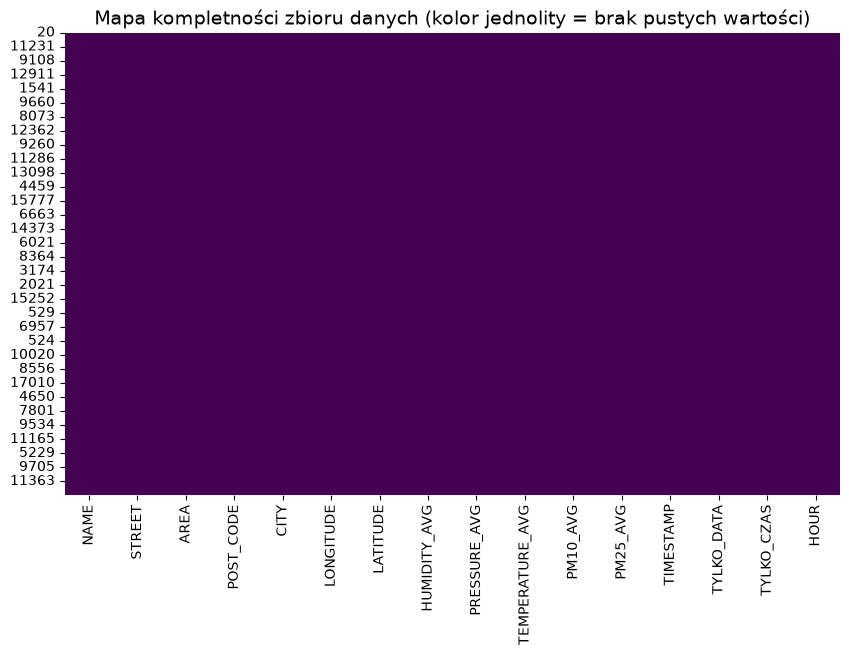

In [206]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_smog.isna(), cbar=False, cmap='viridis')
plt.title('Mapa kompletności zbioru danych (kolor jednolity = brak pustych wartości)', fontsize=14)
plt.show()


Powyższa mapa cieplna (heatmapa) potwierdza całkowitą kompletność analizowanego zbioru danych. Jednolity kolor oraz brak odchyleń na skali udowadniają, że w żadnej z kolumn nie występują już puste wartości (NaN)

### Analiza kompletności danych

<Axes: >

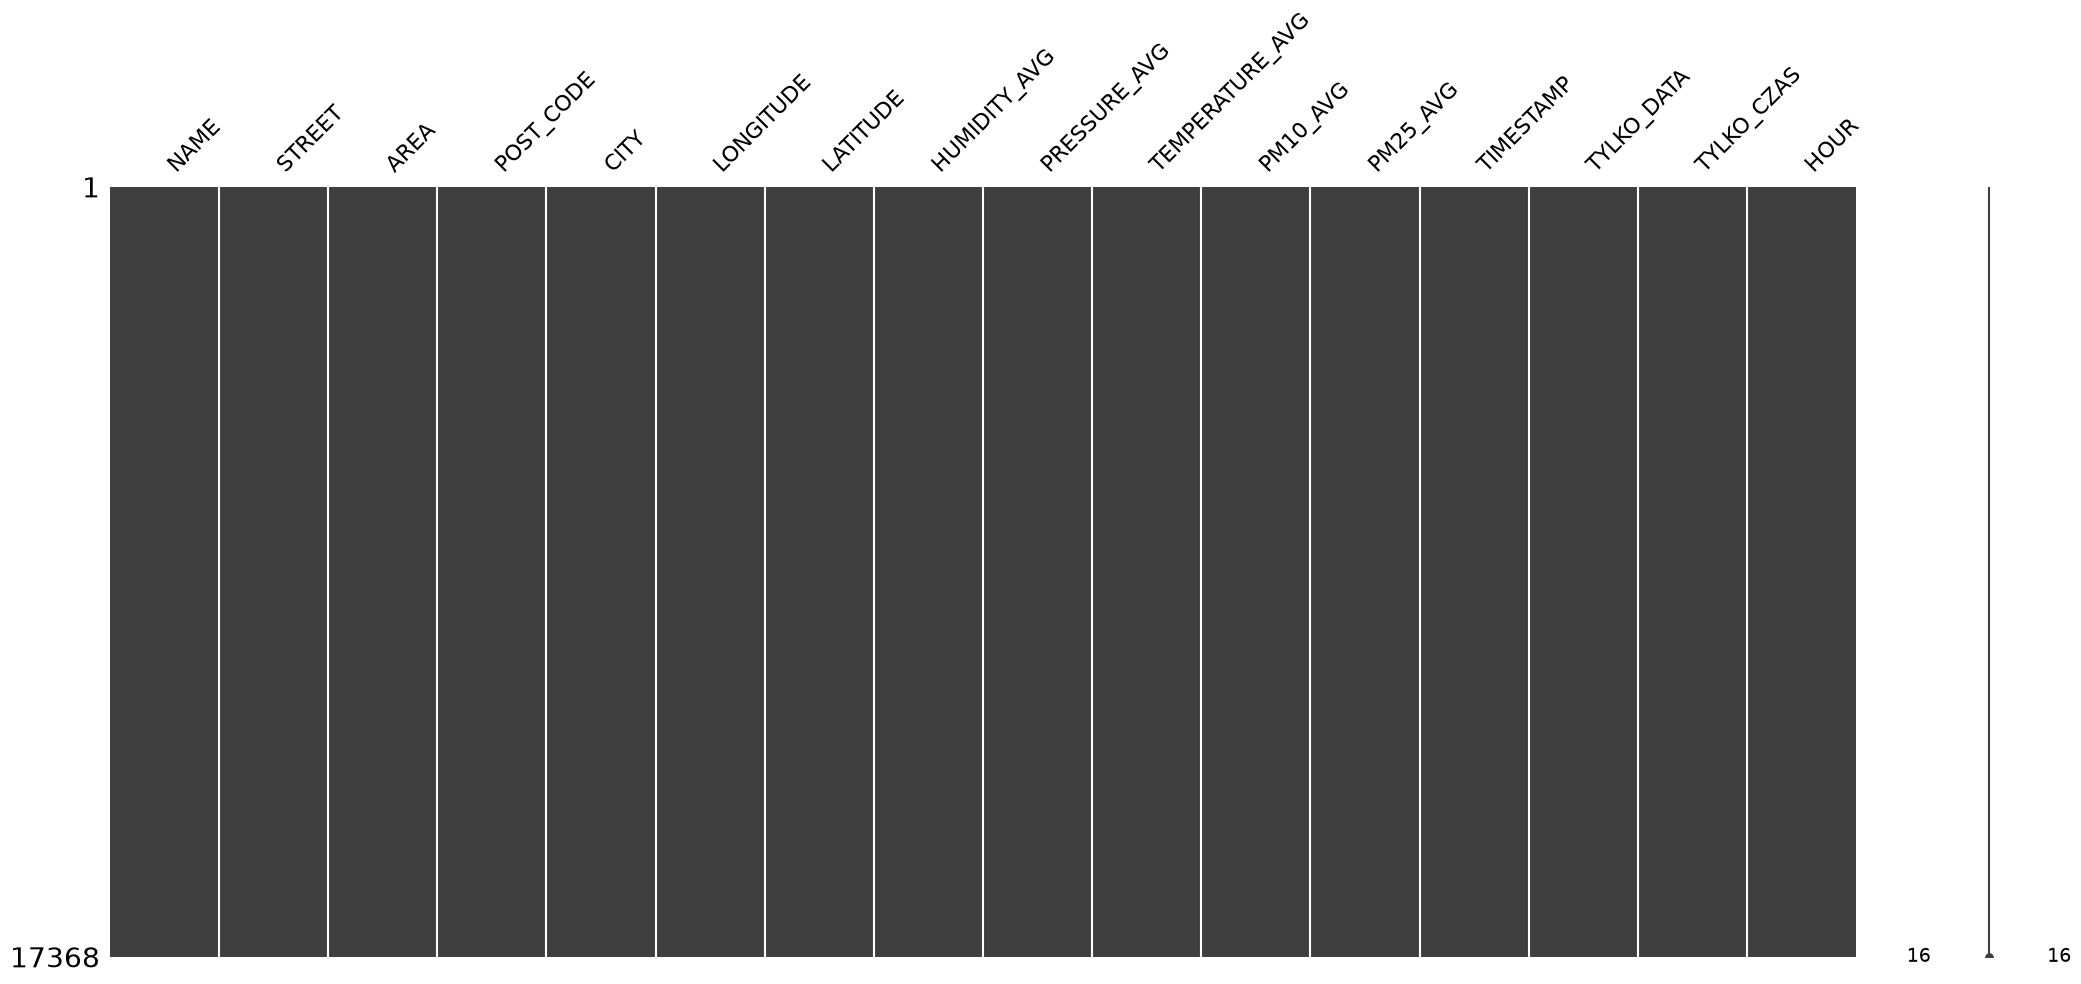

In [142]:
msno.matrix(df_smog)


Zbiór danych obejmujący 17 390 rekordów cechuje się bardzo wysoką kompletnością. Macierz braków ujawniła punktowy, jednoczesny brak odczytów dla zmiennych meteorologicznych (wilgotność, ciśnienie, temperatura) w ułamku obserwacji. Ze względu na zachowanie ciągłości pomiarów zanieczyszczeń (PM) w tych samych wierszach, anomalia wskazuje na jednostkowy błąd czujnika pogody.

#### Uzupełnienie pustych miejsc (NaN) ostatnią prawidłowo odczytaną wartością (forward fill)

In [143]:
df_smog[['HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG']] = df_smog[['HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG']].ffill()


<Axes: >

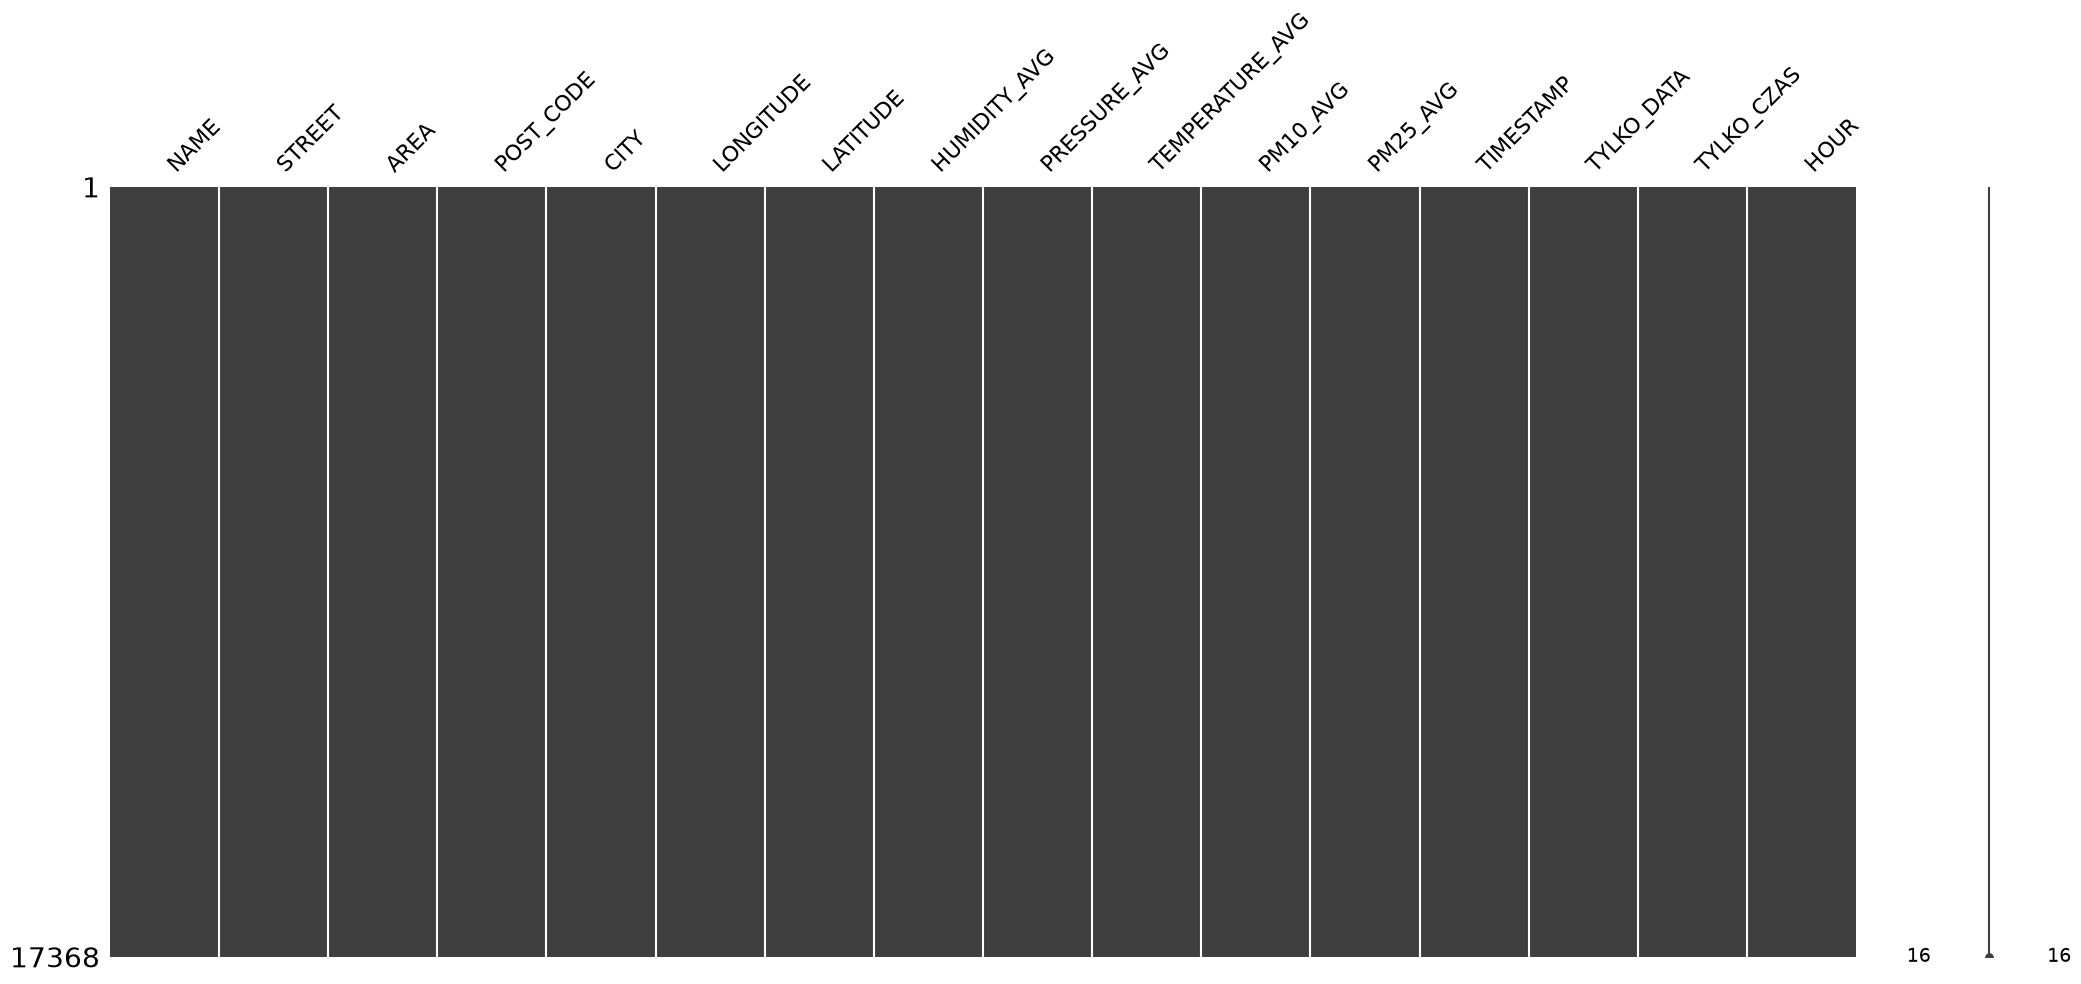

In [144]:
msno.matrix(df_smog)


#### Potwierdzenie braku braków

c:\Users\purch\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\Users\purch\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


<Axes: >

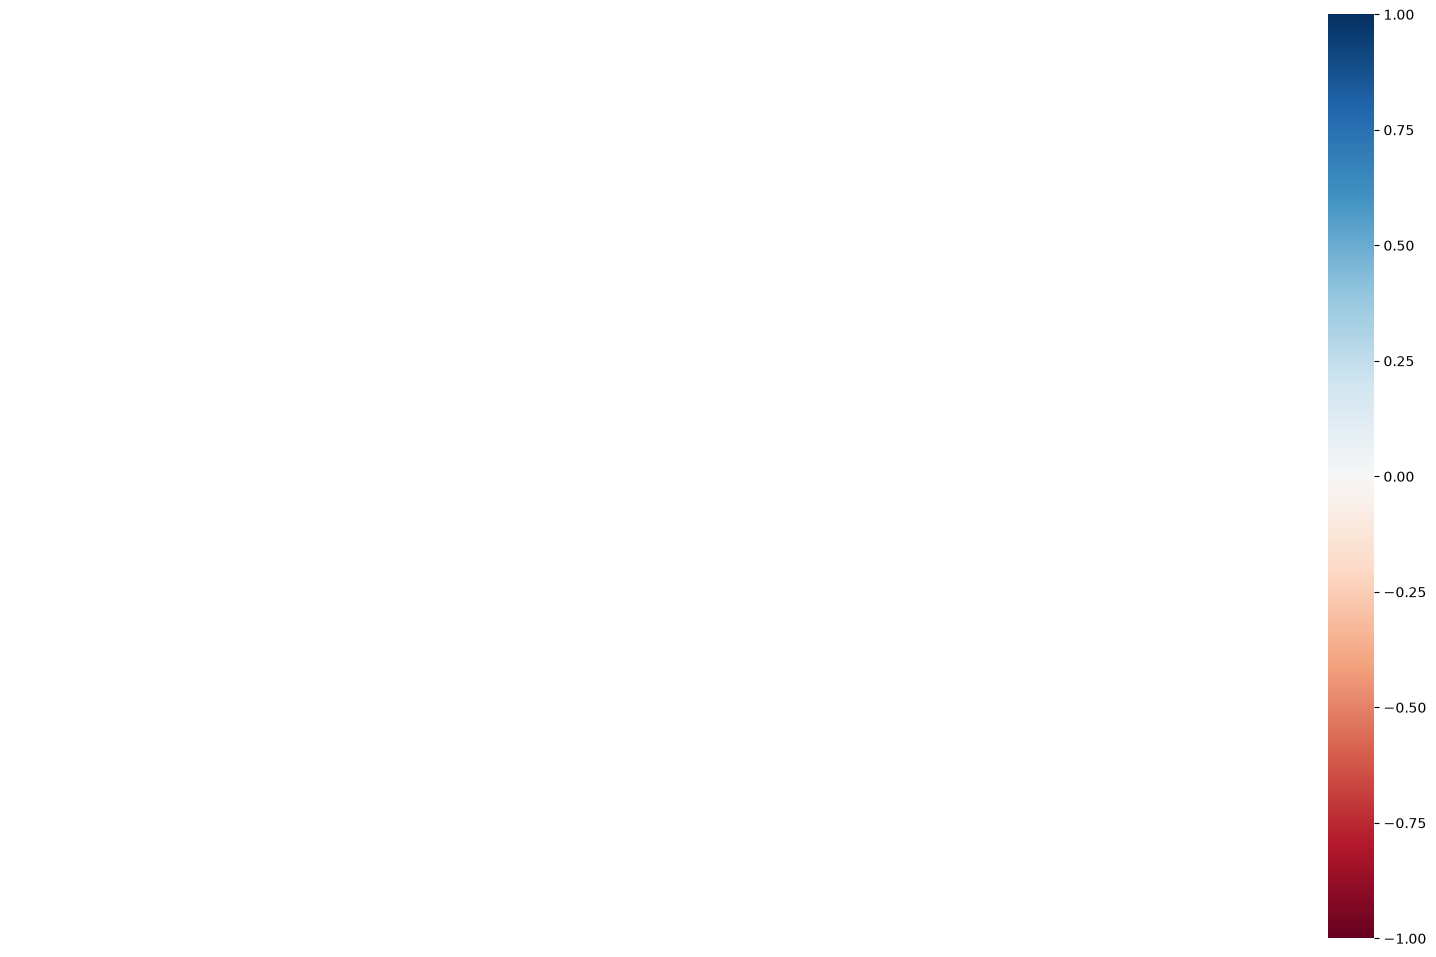

In [145]:
msno.heatmap(df_smog)


Dendogram

c:\Users\purch\AppData\Local\Programs\Python\Python314\Lib\site-packages\scipy\cluster\hierarchy\_hierarchy_impl.py:2849: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([dvw, 0])


<Axes: >

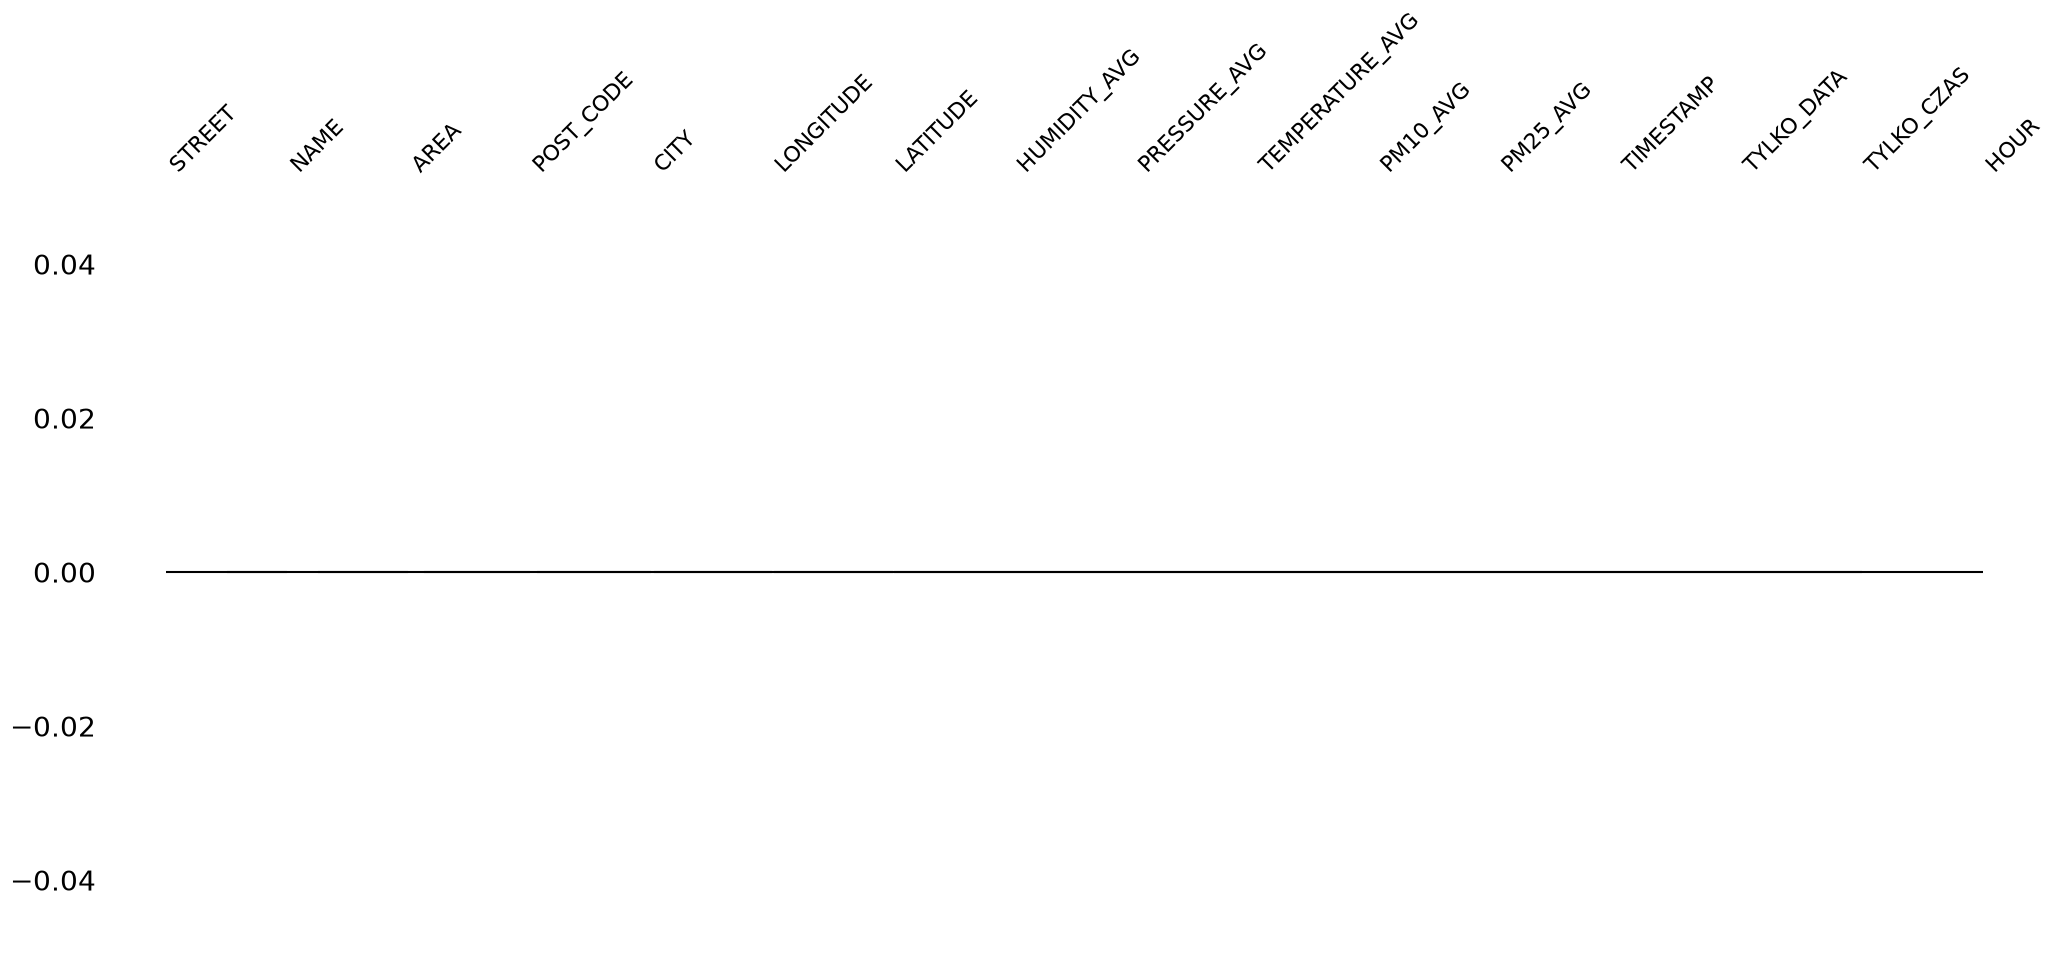

In [146]:
msno.dendrogram(df_smog)


Wykres hierarchiczny korelacji braków przyjmuje postać płaskiej linii. Potwierdza to jednoznacznie, że po przeprowadzonym procesie czyszczenia danych, w zbiorze nie ostały się żadne powiązane ze sobą luki w odczytach. Zbiór jest w 100% kompletny.

### Format float values with precission to 1 [ Convert values to float]

In [27]:
'''for x in smog_columns:
    for z, y in df_smog[f"{x}"].items():
      y = float(y)
    df_smog[f"{x}"] = df_smog[f"{x}"].round(1)'''


'for x in smog_columns:\n    for z, y in df_smog[f"{x}"].items():\n      y = float(y)\n    df_smog[f"{x}"] = df_smog[f"{x}"].round(1)'

### Check, if every area is in place (longitude and latitude are in Polish area)

In [28]:
# Define a function and area latitude and longitude min and max values
for y, x in df_smog['LATITUDE'].items() and df_smog['LONGITUDE'].items():
    x = float(x)

def check_areas(df):
    area_values = {
        "Latitude.North < 54.835563": df_smog['LATITUDE'] < 54.8,
        "Latitude.South > 49.002063": df_smog['LATITUDE'] > 49.0,
        "Longitude.East < 24.145562": df_smog['LONGITUDE'] < 24.2,
        "Longitude.West > 14.124562": df_smog['LONGITUDE'] > 14.0
        }
    return area_values

# Define an object table with the area checker

areas = check_areas(df_smog)

# Print if there are any differences in the areas

for rule, result in areas.items():
    print(f"{rule}: {not result.all()}")


Latitude.North < 54.835563: False
Latitude.South > 49.002063: True
Longitude.East < 24.145562: False
Longitude.West > 14.124562: True


### Check, how many of areas have wrong latitudes\longitudes

In [29]:
# Check, how many differences are in areas

differences = {rule: ~result for rule, result in areas.items()}
summary = {rule: result.sum() for rule, result in differences.items()}

# Print the number of differences

for rule, count in summary.items():
    print(f"{rule}: {count} differences")


Latitude.North < 54.835563: 0 differences
Latitude.South > 49.002063: 11 differences
Longitude.East < 24.145562: 0 differences
Longitude.West > 14.124562: 11 differences


### Rzutowanie kolumn tekstowych na numeryczne (błędy zamieniane na NaN)

In [110]:
cols_to_numeric = ['HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG']
for col in cols_to_numeric:
    df_smog[col] = df_smog[col].astype(str).str.replace(',', '.')
    df_smog[col] = pd.to_numeric(df_smog[col], errors='coerce')


### Usunięcie wierszy z brakami danych (NaN) w kluczowych kolumnach

In [109]:
df_smog = df_smog.dropna(subset=['PM10_AVG', 'PM25_AVG', 'LATITUDE', 'LONGITUDE', 'HUMIDITY_AVG', 'PRESSURE_AVG', 'TEMPERATURE_AVG'])
print(df_smog.info())


<class 'pandas.DataFrame'>
Index: 17368 entries, 20 to 16737
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   NAME             17368 non-null  str           
 1   STREET           17368 non-null  str           
 2   AREA             17368 non-null  str           
 3   POST_CODE        17368 non-null  str           
 4   CITY             17368 non-null  str           
 5   LONGITUDE        17368 non-null  float64       
 6   LATITUDE         17368 non-null  float64       
 7   HUMIDITY_AVG     17368 non-null  float64       
 8   PRESSURE_AVG     17368 non-null  float64       
 9   TEMPERATURE_AVG  17368 non-null  float64       
 10  PM10_AVG         17368 non-null  float64       
 11  PM25_AVG         17368 non-null  float64       
 12  TIMESTAMP        17368 non-null  datetime64[us]
 13  TYLKO_DATA       17368 non-null  object        
 14  TYLKO_CZAS       17368 non-null  object        
 15  

### Analiza Najbardziej Zanieczyszczonych Obszarów

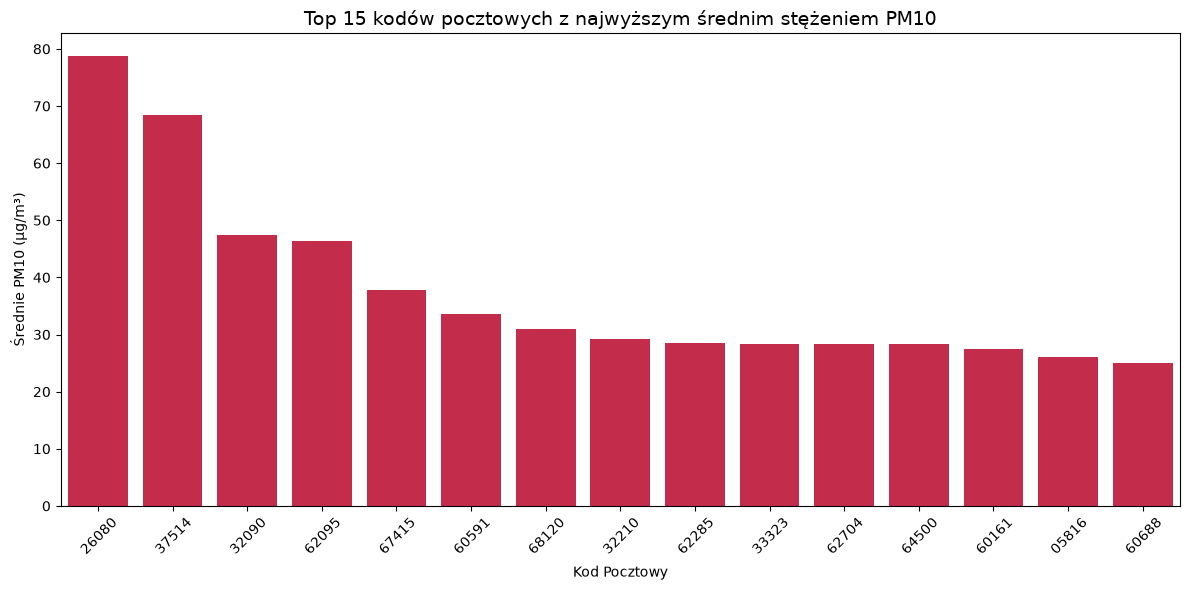

In [ ]:
plt.figure(figsize=(12, 6))
top_15_smog = df_smog.groupby('POST_CODE')['PM10_AVG'].mean().nlargest(15).reset_index()
sns.barplot(data=top_15_smog, x='POST_CODE', y='PM10_AVG', color='crimson')
plt.title('Top 15 kodów pocztowych z najwyższym średnim stężeniem PM10', fontsize=14)
plt.ylabel('Średnie PM10 (µg/m³)')
plt.xlabel('Kod Pocztowy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Rozkład zanieczyszczeń w ujęciu wojewódzkim

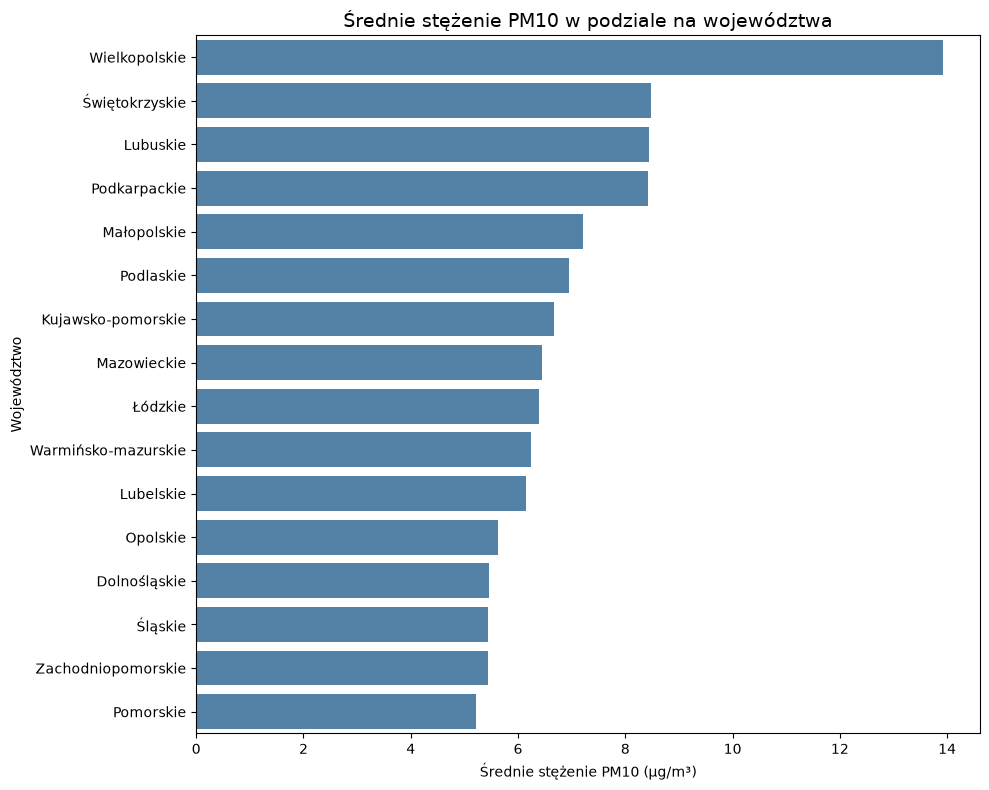

In [154]:
plt.figure(figsize=(10, 8))

# Sortowanie województw od najbardziej do najmniej zanieczyszczonych
kolejnosc = df_smog.groupby('AREA')['PM10_AVG'].mean().sort_values(ascending=False).index

sns.barplot(data=df_smog, y='AREA', x='PM10_AVG', errorbar=None, color='steelblue', order=kolejnosc)

plt.title('Średnie stężenie PM10 w podziale na województwa', fontsize=14)
plt.xlabel('Średnie stężenie PM10 (µg/m³)')
plt.ylabel('Województwo')
plt.tight_layout()
plt.show()


### Analiza korelacji: Temperatura a stężenie PM10

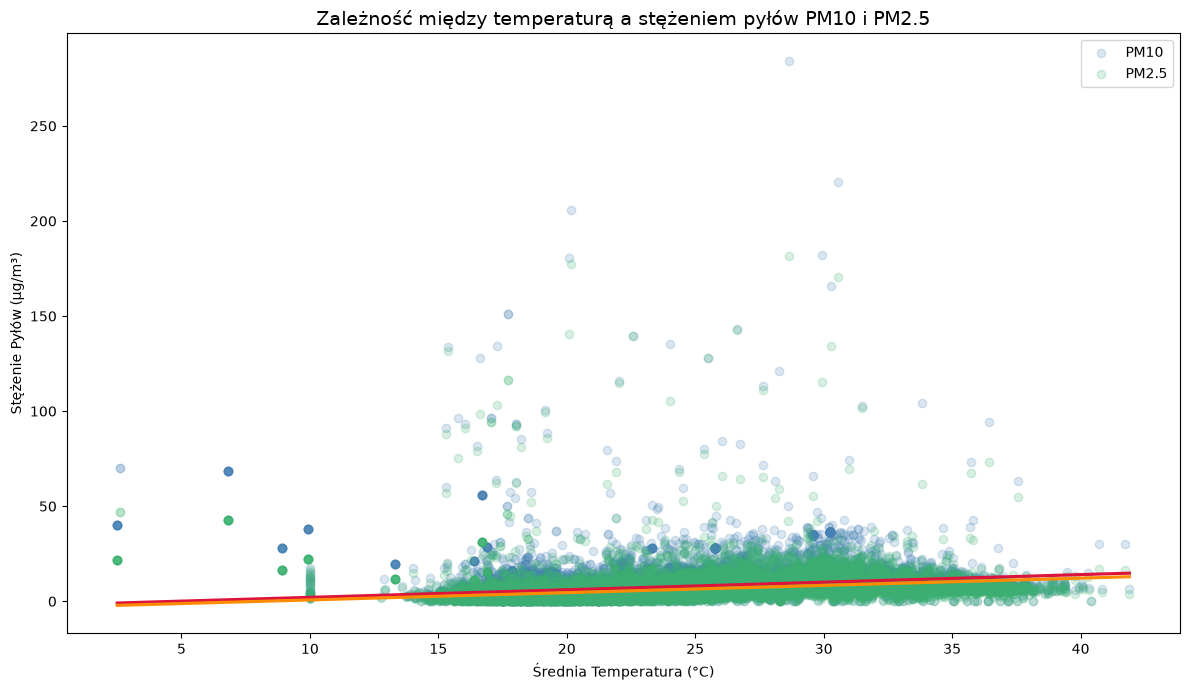

In [ ]:
df_czyste_temp = df_smog[df_smog['TEMPERATURE_AVG'] > 0]
plt.figure(figsize=(12, 7))

# 1. Zmniejszamy kropki (dodajemy parametr scatter_kws z mniejszym 's' i mniejszą 'alpha')
sns.regplot(data=df_czyste_temp, x='TEMPERATURE_AVG', y='PM10_AVG', 
            scatter_kws={'alpha':0.1, 's':15, 'color':'steelblue'}, 
            line_kws={'color':'crimson'}, label='PM10')

sns.regplot(data=df_czyste_temp, x='TEMPERATURE_AVG', y='PM25_AVG', 
            scatter_kws={'alpha':0.1, 's':15, 'color':'mediumseagreen'}, 
            line_kws={'color':'darkorange'}, label='PM2.5')

# 2. ODCINAMY OŚ Y! Pokazujemy tylko wartości od 0 do 100 µg/m³
plt.ylim(-5, 100) 

plt.title('Zależność między temperaturą a stężeniem pyłów (z powiększeniem głównego skupiska)', fontsize=14)
plt.xlabel('Średnia Temperatura (°C)')
plt.ylabel('Stężenie Pyłów (µg/m³)')
plt.legend()
plt.tight_layout()
plt.show()


Analiza korelacji PM10 i PM2.5 z temperaturą:
Brak silnego związku z temperaturą: linie trendu (czerwona i pomarańczowa) lekko pną się w górę, szeroka "chmura" punktów wskazuje, że sama temperatura nie jest głównym czynnikiem napędzającym smog w lipcu.
Wysoka jakość powietrza -  większość odczytów (potężne zagęszczenie na samym dole wykresu) znajduje się poniżej bezpiecznego progu 50 µg/m³.
Ścisła współzależność frakcji: Kropki zielone (PM2.5) i niebieskie (PM10) oraz ich linie trendu nakładają się na siebie niemal idealnie, co potwierdza, że pochodzą z tych samych źródeł emisji.

### Analiza regionalna zanieczyszczeń (PM10 vs PM2.5)

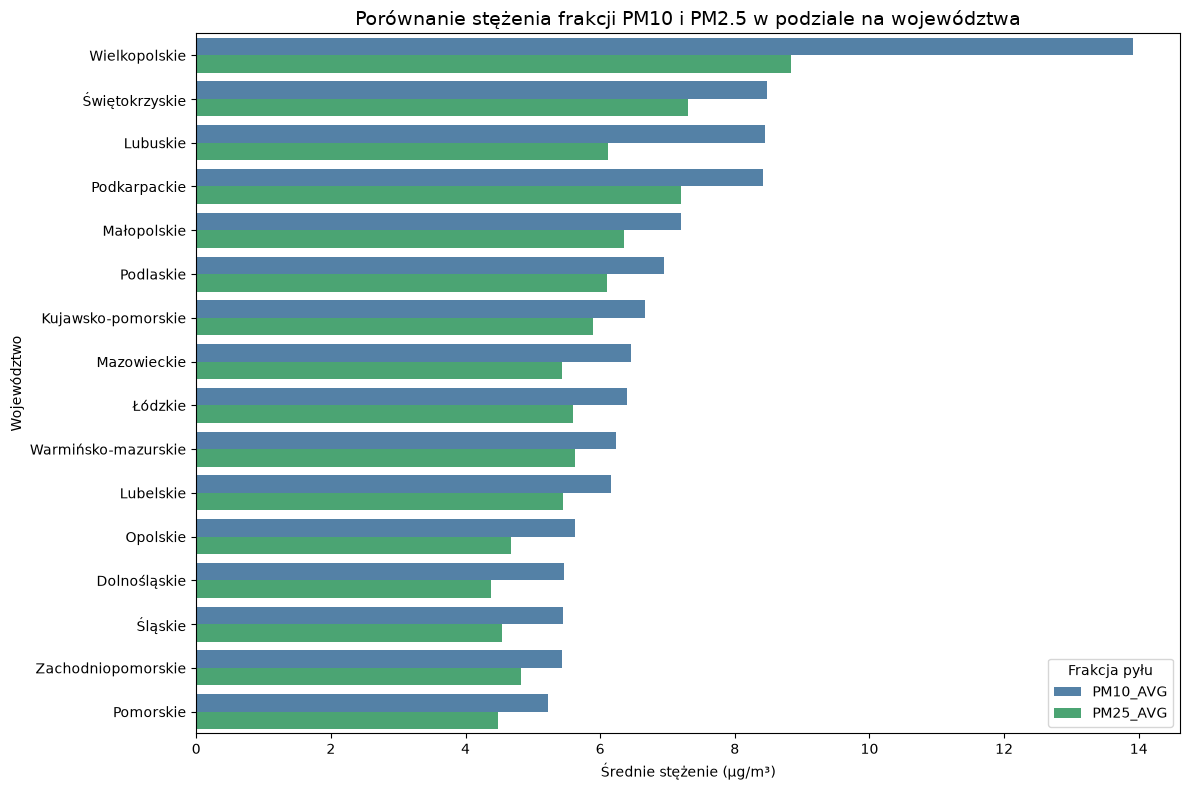

In [178]:
plt.figure(figsize=(12, 8))
df_grouped = df_smog.groupby('AREA')[['PM10_AVG', 'PM25_AVG']].mean().sort_values(by='PM10_AVG', ascending=False).reset_index()
df_melted = df_grouped.melt(id_vars='AREA', var_name='Frakcja', value_name='Średnie stężenie')
sns.barplot(data=df_melted, y='AREA', x='Średnie stężenie', hue='Frakcja', palette=['steelblue', 'mediumseagreen'])
plt.title('Porównanie stężenia frakcji PM10 i PM2.5 w podziale na województwa', fontsize=14)
plt.xlabel('Średnie stężenie (µg/m³)')
plt.ylabel('Województwo')
plt.legend(title='Frakcja pyłu')
plt.tight_layout()
plt.show()


<Axes: xlabel='TEMPERATURE_AVG', ylabel='PM25_AVG'>

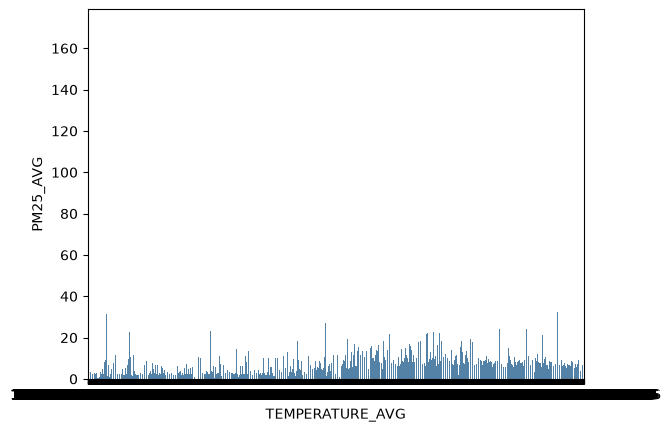

In [170]:
sns.barplot(data=df_smog,x='TEMPERATURE_AVG',y='PM25_AVG',errorbar=None,estimator=np.mean,color='steelblue')


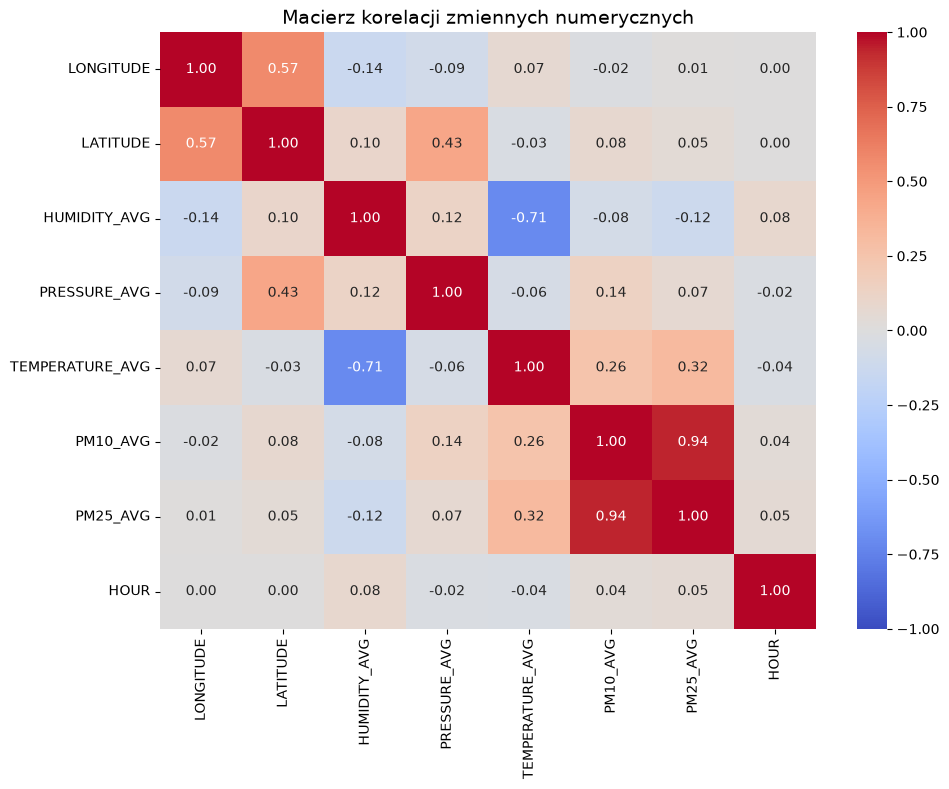

In [179]:
plt.figure(figsize=(10, 8))
korelacje = df_smog.corr(numeric_only=True)
sns.heatmap(korelacje, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Macierz korelacji zmiennych numerycznych', fontsize=14)
plt.tight_layout()
plt.show()


Usuwanie duplikatów

In [180]:
korelacje_lista = korelacje.unstack().sort_values(key=abs, ascending=False).drop_duplicates()
korelacje_lista = korelacje_lista[korelacje_lista != 1.0]
print("Najsilniejsze znalezione korelacje w danych:")


Najsilniejsze znalezione korelacje w danych:


In [213]:
print(korelacje_lista.head(10))


PM25_AVG         PM10_AVG           0.944787
HUMIDITY_AVG     TEMPERATURE_AVG   -0.709439
LONGITUDE        LATITUDE           0.573475
PRESSURE_AVG     LATITUDE           0.433271
TEMPERATURE_AVG  PM25_AVG           0.315836
PM10_AVG         TEMPERATURE_AVG    0.255416
HUMIDITY_AVG     LONGITUDE         -0.138984
PM10_AVG         PRESSURE_AVG       0.138918
HUMIDITY_AVG     PM25_AVG          -0.121143
PRESSURE_AVG     HUMIDITY_AVG       0.118388
dtype: float64


Potwierdzona zostaje dominująca zależność między frakcjami PM2.5 a PM10 (0.94).
Na drugim miejscu plasuje się silna ujemna korelacja (-0.71) między wilgotnością a temperaturą.
Pojawiła się zależność geograficzna: Długość i szerokość geograficzna (0.57 i 0.43 z innymi zmiennymi) sugerują, że ułożenie stacji ma pewien matematyczny wpływ na układ danych.

### Histogram dla PM10

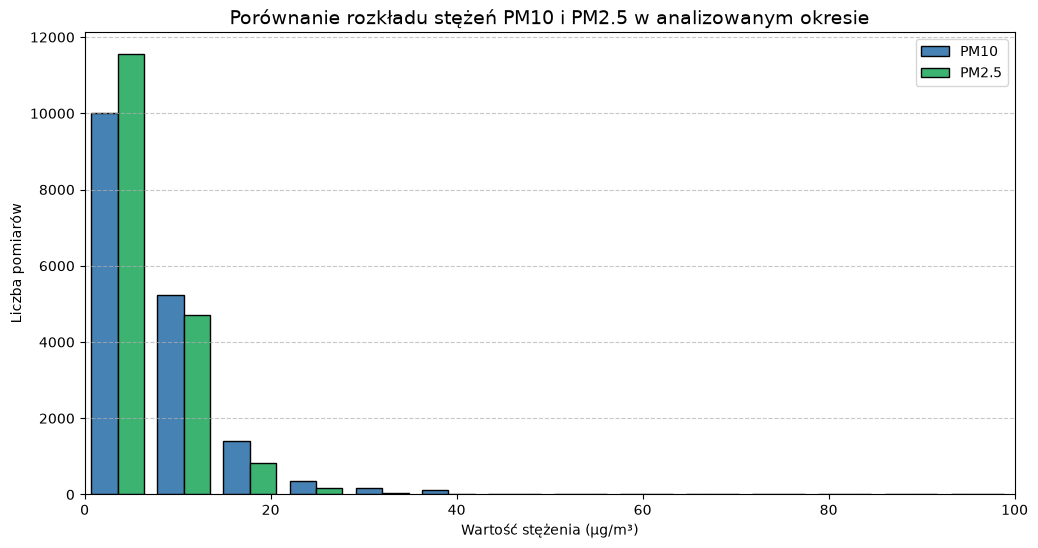

In [182]:
plt.figure(figsize=(12, 6))

plt.hist([df_smog['PM10_AVG'], df_smog['PM25_AVG']], bins=40, 
         color=['steelblue', 'mediumseagreen'], label=['PM10', 'PM2.5'], edgecolor='black')
plt.xlim(0, 100)
plt.title('Porównanie rozkładu stężeń PM10 i PM2.5 w analizowanym okresie', fontsize=14)
plt.ylabel('Liczba pomiarów')
plt.xlabel('Wartość stężenia (µg/m³)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Zbieżność kształtu rozkładu: Obie frakcje charakteryzują się identycznym, prawoskośnym kształtem rozkładu. 
Oba pyły zachowują się w środowisku w ten sam sposób i podlegają tym samym trendom

### Analiza współzależności frakcji pyłów

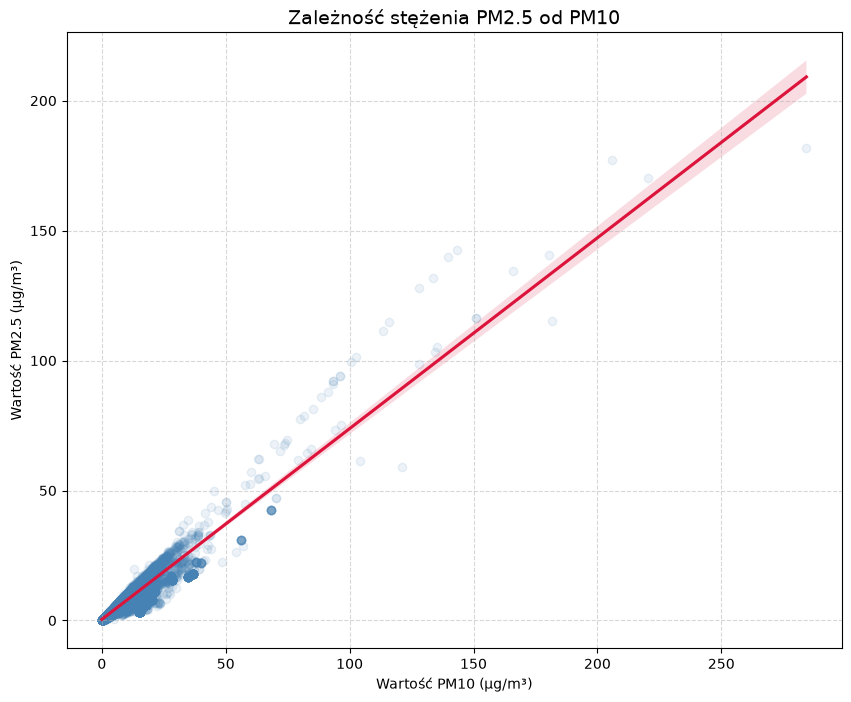

In [184]:
plt.figure(figsize=(10, 8))
sns.regplot(data=df_smog, x='PM10_AVG', y='PM25_AVG', 
            scatter_kws={'alpha': 0.1, 'color': 'steelblue'}, 
            line_kws={'color': 'crimson'})
plt.title('Zależność stężenia PM2.5 od PM10', fontsize=14)
plt.xlabel('Wartość PM10 (µg/m³)')
plt.ylabel('Wartość PM2.5 (µg/m³)')
plt.grid(linestyle='--', alpha=0.5)
plt.show()


Analiza potwierdza ekstremalnie silną korelację.
Punkty układają się w bardzo wąskim, zwartym paśmie wzdłuż linii regresji. Oznacza to, że proporcja szkodliwszego PM2.5 w ogólnej puli PM10 jest wysoce przewidywalna i stała.

### Wykres liniowy - zmiana stężenia pyłów zawieszonych (PM10 i PM2.5) na przestrzeni badanego tygodnia (17-23 lipca 2026 r.)

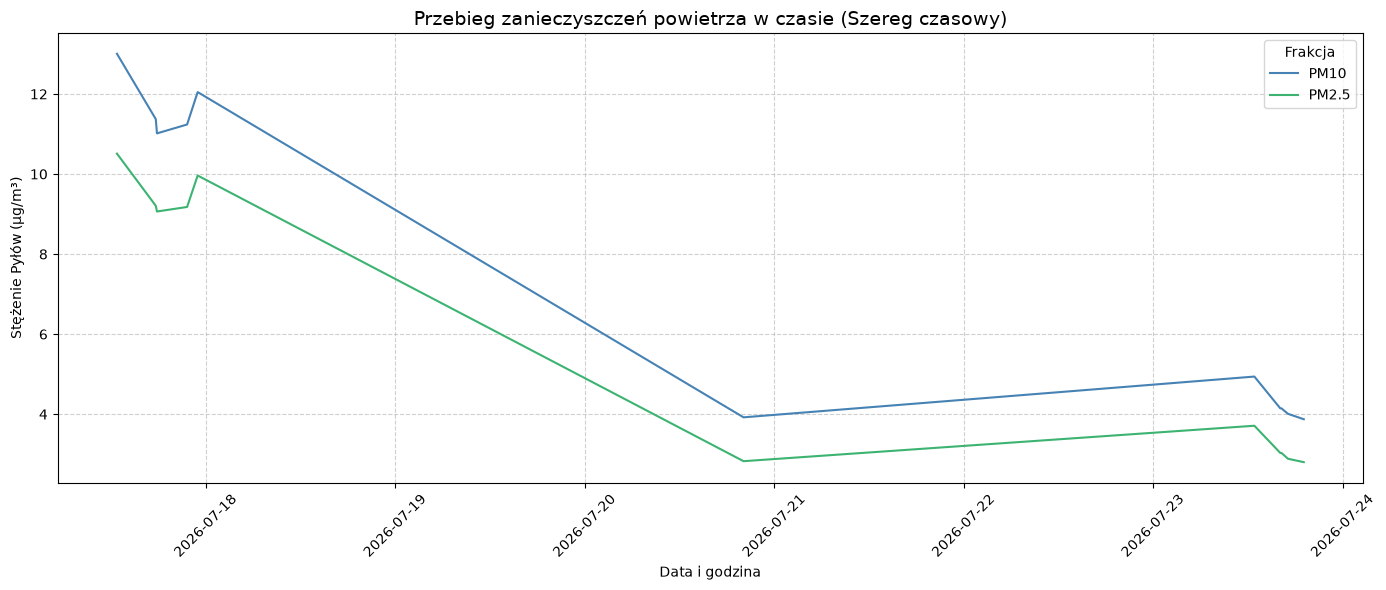

In [188]:
plt.figure(figsize=(14, 6))
df_smog['TIMESTAMP'] = pd.to_datetime(df_smog['TIMESTAMP'], errors='coerce')
sns.lineplot(data=df_smog, x='TIMESTAMP', y='PM10_AVG', label='PM10', color='steelblue', errorbar=None)
sns.lineplot(data=df_smog, x='TIMESTAMP', y='PM25_AVG', label='PM2.5', color='mediumseagreen', errorbar=None)
plt.title('Przebieg zanieczyszczeń powietrza w czasie (Szereg czasowy)', fontsize=14)
plt.xlabel('Data i godzina')
plt.ylabel('Stężenie Pyłów (µg/m³)')
plt.xticks(rotation=45) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Frakcja')
plt.tight_layout()
plt.show()


### Wykres pudełkowy (boxplot) dla regionów

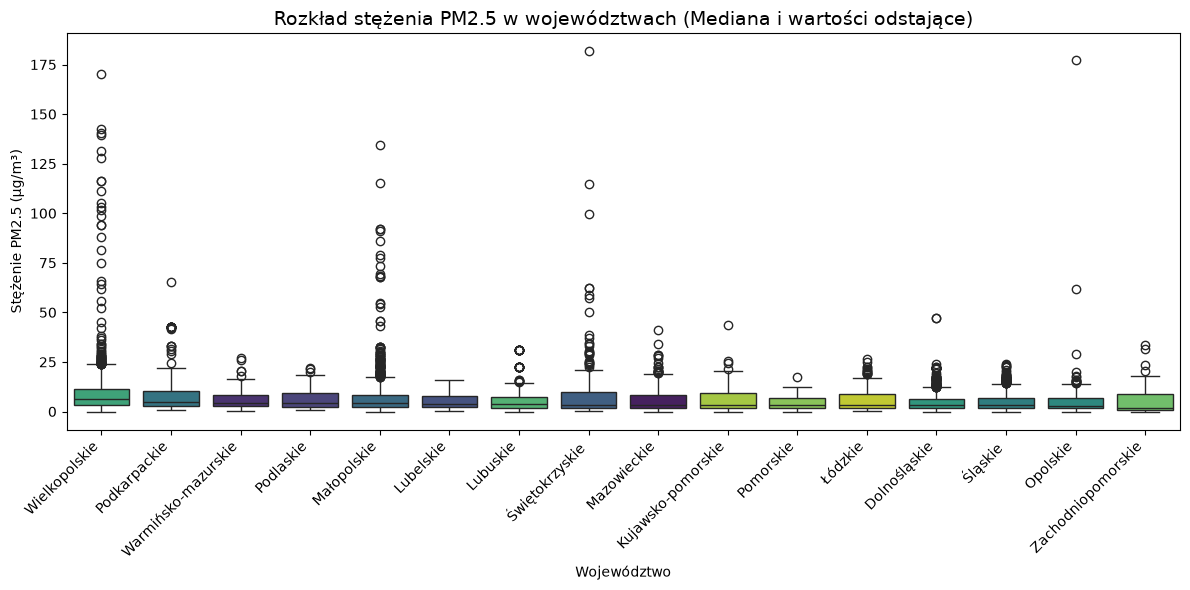

In [191]:
plt.figure(figsize=(12, 6))
kolejnosc = df_smog.groupby('AREA')['PM25_AVG'].median().sort_values(ascending=False).index
sns.boxplot(x='AREA', y='PM25_AVG', data=df_smog, order=kolejnosc, palette='viridis', hue='AREA', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('Rozkład stężenia PM2.5 w województwach (Mediana i wartości odstające)', fontsize=14)
plt.ylabel('Stężenie PM2.5 (µg/m³)')
plt.xlabel('Województwo')
plt.tight_layout()
plt.show()


Pudełka Są bardzo płaskie i leżą na samym dole wykresu. Oznacza to, że przez większość czasu (w 50% pomiarów) powietrze w każdym województwie jest bardzo czyste i stabilne.
Czarne kropki (wartości odstające / outliery) Pokazują pojedyncze, ekstremalne strzały smogu.

### Definiowanie funkcji do obliczenia współczynnika zmienności (w procentach)


In [214]:
def wsp_zmiennosci(x):
    return (x.std() / x.mean()) * 100


### Wywoływanie interesujących nas statystyk dla konkretnej kolumny (lub kilku kolumn)

In [208]:
def q1(x): return x.quantile(0.25)
def q3(x): return x.quantile(0.75)
statystyki = df_smog[['PM10_AVG', 'PM25_AVG']].agg([
    'mean',           # Średnia
    'median',         # Mediana
    'std',            # Odchylenie standardowe
    wsp_zmiennosci,   # Współczynnik zmienności (nasza funkcja zdefiniowana wyżej)
    q1,               # Pierwszy kwartyl
    q3                # Trzeci kwartyl
])
statystyki.index = ['Średnia', 'Mediana', 'Odch. standardowe', 'Wsp. zmienności (%)', 'Kwartyl 1 (Q1)', 'Kwartyl 3 (Q3)']
display(statystyki.round(2))


,PM10_AVG,PM25_AVG
Średnia,7.62,6.03
Mediana,5.18,3.95
Odch. standardowe,9.10,7.07
Wsp. zmienności (%),119.46,117.32
Kwartyl 1 (Q1),2.50,2.16
Kwartyl 3 (Q3),10.26,8.35


### Najwyższe zanieczyszczenie PM10

In [207]:
print("Top 5 najbardziej zanieczyszczonych pomiarów (PM10):")
kolumny_do_pokazania = ['TIMESTAMP', 'CITY', 'AREA', 'NAME', 'PM10_AVG', 'PM25_AVG']
top_5_smog = df_smog.nlargest(5, 'PM10_AVG')[kolumny_do_pokazania]

display(top_5_smog)


Top 5 najbardziej zanieczyszczonych pomiarów (PM10):


,TIMESTAMP,CITY,AREA,NAME,PM10_AVG,PM25_AVG
877,2026-07-17 12:43:58,ROGOWICE,Świętokrzyskie,SZKOŁA PODSTAWOWA W ROGOWICACH,284.341667,181.666667
1420,2026-07-17 12:43:58,BIAŁĘŻYN,Wielkopolskie,SZKOŁA PODSTAWOWA IM. LEONA MASIAKOWSKIEGO W B...,220.600000,170.320000
7082,2026-07-17 22:57:28,STRZELECZKI,Opolskie,SZKOŁA PODSTAWOWA W STRZELECZKACH,205.710000,177.180000
6050,2026-07-17 21:37:05,SŁOMNIKI,Małopolskie,SZKOŁA PODSTAWOWA W ZESPOLE SZKÓŁ OGÓLNOKSZTAŁ...,181.862500,115.250000
17226,2026-07-23 19:04:41,BIAŁĘŻYN,Wielkopolskie,SZKOŁA PODSTAWOWA IM. LEONA MASIAKOWSKIEGO W B...,180.600000,140.560000


### Rozkład godzinowy stężenia PM10 i PM2.5 - najwyższe stężenie w ciągu doby.

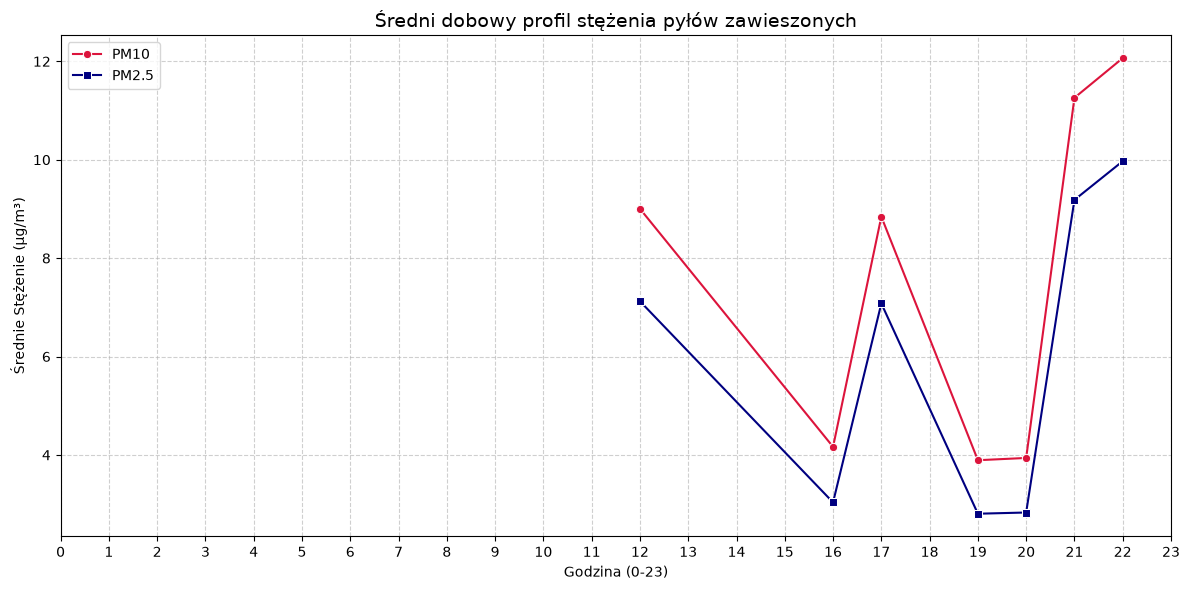

In [90]:
df_smog['TIMESTAMP'] = pd.to_datetime(df_smog['TIMESTAMP'], errors='coerce')
df_smog['HOUR'] = df_smog['TIMESTAMP'].dt.hour

# 2. Rysujemy wykres używając nowej kolumny 'HOUR'
plt.figure(figsize=(12, 6))

# Grupowanie po godzinie (HOUR), a nie TYLKO_CZAS
hourly_trend = df_smog.groupby('HOUR')[['PM10_AVG', 'PM25_AVG']].mean().reset_index()

sns.lineplot(x='HOUR', y='PM10_AVG', data=hourly_trend, marker='o', label='PM10', color='crimson')
sns.lineplot(x='HOUR', y='PM25_AVG', data=hourly_trend, marker='s', label='PM2.5', color='navy')

plt.title('Średni dobowy profil stężenia pyłów zawieszonych', fontsize=14)
plt.xlabel('Godzina (0-23)')
plt.ylabel('Średnie Stężenie (µg/m³)')

# Teraz to zadziała, bo na osi X mamy liczby całkowite od 0 do 23
plt.xticks(range(0, 24)) 
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### MAPA ZANIECZYSZCZEŃ

In [212]:
df_schools = df_smog.groupby(['NAME', 'LATITUDE', 'LONGITUDE'])['PM10_AVG'].mean().reset_index()
m = folium.Map(location=[52.0, 19.0], zoom_start=6)

for idx, row in df_schools.iterrows():
    # Definiujemy kolory ostrzegawcze
    if row['PM10_AVG'] <= 20:
        color = 'green'
    elif row['PM10_AVG'] <= 50:
        color = 'orange'
    else:
        color = 'red'
        
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=6,
        popup=f"<b>{row['NAME']}</b><br>Średnie PM10: {row['PM10_AVG']:.1f} µg/m³",
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7
    ).add_to(m)
    m.save('mapa_szkol.html')
    m


### Wnioski z przeprowadzonych badań

In [218]:
md(f"# Wyniki dla PM10:\nŚrednia (mean) wynosi ok. {statystyki.loc['Średnia', 'PM10_AVG']:.2f}, podczas gdy mediana (median) to zaledwie {statystyki.loc['Mediana', 'PM10_AVG']:.2f}. \n- Interpretacja: Mediana mówi nam, że w dokładnie połowie badanych przypadków zanieczyszczenie pyłem PM10 wynosiło {statystyki.loc['Mediana', 'PM10_AVG']:.2f} lub mniej. Dobowa norma alarmowa to 50. Ponieważ średnia jest zauważalnie wyższa od mediany, mamy tu do czynienia z rozkładem silnie prawoskośnym. Oznacza to, że przez większość czasu powietrze jest bardzo czyste, ale występują nagłe, rzadkie godziny z gigantycznym smogiem, które matematycznie \"ciągną\" średnią w górę.")


# Wyniki dla PM10:
Średnia (mean) wynosi ok. 7.62, podczas gdy mediana (median) to zaledwie 5.18. 
- Interpretacja: Mediana mówi nam, że w dokładnie połowie badanych przypadków zanieczyszczenie pyłem PM10 wynosiło 5.18 lub mniej. Dobowa norma alarmowa to 50. Ponieważ średnia jest zauważalnie wyższa od mediany, mamy tu do czynienia z rozkładem silnie prawoskośnym. Oznacza to, że przez większość czasu powietrze jest bardzo czyste, ale występują nagłe, rzadkie godziny z gigantycznym smogiem, które matematycznie "ciągną" średnią w górę.

In [216]:
md(f"Odchylenie standardowe (std) wynosi {statystyki.loc['Odch. standardowe', 'PM10_AVG']:.2f}, a współczynnik zmienności osiągnął {statystyki.loc['Wsp. zmienności (%)', 'PM10_AVG']:.2f}%\n- Interpretacja: Współczynnik zmienności powyżej 100% oznacza ekstremalnie wysoki rozrzut danych. Odchylenie standardowe jest prawie dwukrotnie wyższe od samej średniej. Zjawisko smogu jest niestabilne i epizodyczne. Wysoka zmienność wskazuje na niestabilność warunków atmosferycznych.")


Odchylenie standardowe (std) wynosi 9.10, a współczynnik zmienności osiągnął 119.46%
- Interpretacja: Współczynnik zmienności powyżej 100% oznacza ekstremalnie wysoki rozrzut danych. Odchylenie standardowe jest prawie dwukrotnie wyższe od samej średniej. Zjawisko smogu jest niestabilne i epizodyczne. Wysoka zmienność wskazuje na niestabilność warunków atmosferycznych.

In [219]:
md(f"Dolny kwartyl (Q1) to {statystyki.loc['Kwartyl 1 (Q1)', 'PM10_AVG']:.2f}, a górny kwartyl (Q3) to {statystyki.loc['Kwartyl 3 (Q3)', 'PM10_AVG']:.2f}. \n- Interpretacja: Te liczby oznaczają, że aż połowa (środkowe 50%) wszystkich zebranych pomiarów jest w przedziale między {statystyki.loc['Kwartyl 1 (Q1)', 'PM10_AVG']:.2f} a {statystyki.loc['Kwartyl 3 (Q3)', 'PM10_AVG']:.2f}, Q3 wynosi {statystyki.loc['Kwartyl 3 (Q3)', 'PM10_AVG']:.2f}, co oznacza, że aż 75% wszystkich pomiarów jest niższych niż {statystyki.loc['Kwartyl 3 (Q3)', 'PM10_AVG']:.2f}. Problemy ze smogiem (i za podwyższoną średnią oraz ogromne odchylenie) odpowiadają najwyższe 25% pomiarów.")


Dolny kwartyl (Q1) to 2.50, a górny kwartyl (Q3) to 10.26. 
- Interpretacja: Te liczby oznaczają, że aż połowa (środkowe 50%) wszystkich zebranych pomiarów jest w przedziale między 2.50 a 10.26, Q3 wynosi 10.26, co oznacza, że aż 75% wszystkich pomiarów jest niższych niż 10.26. Problemy ze smogiem (i za podwyższoną średnią oraz ogromne odchylenie) odpowiadają najwyższe 25% pomiarów.

In [220]:
md(f"# Wyniki dla PM2.5:\nŚrednia (mean) wynosi ok. {statystyki.loc['Średnia', 'PM25_AVG']:.2f}, podczas gdy mediana (median) to zaledwie {statystyki.loc['Mediana', 'PM25_AVG']:.2f}. \n- Interpretacja: Mediana mówi nam, że w dokładnie połowie badanych przypadków zanieczyszczenie pyłem PM2.5 wynosiło zaledwie {statystyki.loc['Mediana', 'PM25_AVG']:.2f} lub mniej. Dobowa norma alarmowa to 15 (wg WHO). Ponieważ średnia jest zauważalnie wyższa od mediany, mamy tu do czynienia z rozkładem silnie prawoskośnym. Oznacza to, że przez większość czasu powietrze jest bardzo czyste, ale występują nagłe, rzadkie godziny z gigantycznym smogiem, które matematycznie \"ciągną\" średnią w górę.")


# Wyniki dla PM2.5:
Średnia (mean) wynosi ok. 6.03, podczas gdy mediana (median) to zaledwie 3.95. 
- Interpretacja: Mediana mówi nam, że w dokładnie połowie badanych przypadków zanieczyszczenie pyłem PM2.5 wynosiło zaledwie 3.95 lub mniej. Dobowa norma alarmowa to 15 (wg WHO). Ponieważ średnia jest zauważalnie wyższa od mediany, mamy tu do czynienia z rozkładem silnie prawoskośnym. Oznacza to, że przez większość czasu powietrze jest bardzo czyste, ale występują nagłe, rzadkie godziny z gigantycznym smogiem, które matematycznie "ciągną" średnią w górę.

In [221]:
md(f"Odchylenie standardowe (std) wynosi {statystyki.loc['Odch. standardowe', 'PM25_AVG']:.2f}, a współczynnik zmienności osiągnął {statystyki.loc['Wsp. zmienności (%)', 'PM25_AVG']:.2f}%\n- Interpretacja: Współczynnik zmienności powyżej 100% oznacza ekstremalnie wysoki rozrzut danych. Odchylenie standardowe jest prawie dwukrotnie wyższe od samej średniej. Zjawisko smogu jest niestabilne i epizodyczne. Wysoka zmienność wskazuje na niestabilność warunków atmosferycznych.")


Odchylenie standardowe (std) wynosi 7.07, a współczynnik zmienności osiągnął 117.32%
- Interpretacja: Współczynnik zmienności powyżej 100% oznacza ekstremalnie wysoki rozrzut danych. Odchylenie standardowe jest prawie dwukrotnie wyższe od samej średniej. Zjawisko smogu jest niestabilne i epizodyczne. Wysoka zmienność wskazuje na niestabilność warunków atmosferycznych.

In [222]:
md(f"Dolny kwartyl (Q1) to {statystyki.loc['Kwartyl 1 (Q1)', 'PM25_AVG']:.2f}, a górny kwartyl (Q3) to {statystyki.loc['Kwartyl 3 (Q3)', 'PM25_AVG']:.2f}. \n- Interpretacja: Te liczby oznaczają, że aż połowa (środkowe 50%) wszystkich zebranych pomiarów jest w przedziale między {statystyki.loc['Kwartyl 1 (Q1)', 'PM25_AVG']:.2f} a {statystyki.loc['Kwartyl 3 (Q3)', 'PM25_AVG']:.2f}, Q3 wynosi {statystyki.loc['Kwartyl 3 (Q3)', 'PM25_AVG']:.2f}, co oznacza, że aż 75% wszystkich pomiarów jest niższych niż {statystyki.loc['Kwartyl 3 (Q3)', 'PM25_AVG']:.2f}. Problemy ze smogiem (i za podwyższoną średnią oraz ogromne odchylenie) odpowiadają najwyższe 25% pomiarów.")


Dolny kwartyl (Q1) to 2.16, a górny kwartyl (Q3) to 8.35. 
- Interpretacja: Te liczby oznaczają, że aż połowa (środkowe 50%) wszystkich zebranych pomiarów jest w przedziale między 2.16 a 8.35, Q3 wynosi 8.35, co oznacza, że aż 75% wszystkich pomiarów jest niższych niż 8.35. Problemy ze smogiem (i za podwyższoną średnią oraz ogromne odchylenie) odpowiadają najwyższe 25% pomiarów.

### Save dataframe to csv file **Always put as a last cell !**

In [223]:
ts = dt.datetime.now().strftime("%Y%m%d_%H-%M")
df_smog.to_csv(f"../tests/smog_raport_raw{ts}.csv", index=False)
